# Inflation Forecast — Exploratory Data Analysis
Covers: time series plots, summary stats, ACF/PACF, and seasonal decomposition.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/macro_data.csv', index_col=0, parse_dates=True)
print(df.shape)
df.head()

(313, 5)


,CPI,UNRATE,M2,OIL,FEDFUNDS
2000-01-01,169.3,4.0,4667.6,27.259474,5.45
2000-02-01,170.0,4.1,4680.9,29.366000,5.73
2000-03-01,171.0,4.0,4711.7,29.841739,5.85
2000-04-01,170.9,3.8,4767.8,25.722105,6.02
2000-05-01,171.2,4.0,4755.7,28.788182,6.27


## 1. Summary Statistics

In [2]:
df.describe().round(2)

,CPI,UNRATE,M2,OIL,FEDFUNDS
count,313.00,313.00,313.00,313.00,313.00
mean,233.77,5.64,11820.35,63.72,2.01
std,41.72,1.94,5642.20,24.82,2.03
min,169.30,3.40,4667.60,16.55,0.05
25%,201.90,4.20,6893.60,45.18,0.15
50%,231.68,5.00,10508.10,62.72,1.26
75%,255.80,6.20,14886.80,81.39,3.94
max,327.46,14.80,22667.30,133.88,6.54


## 2. Time Series Plots

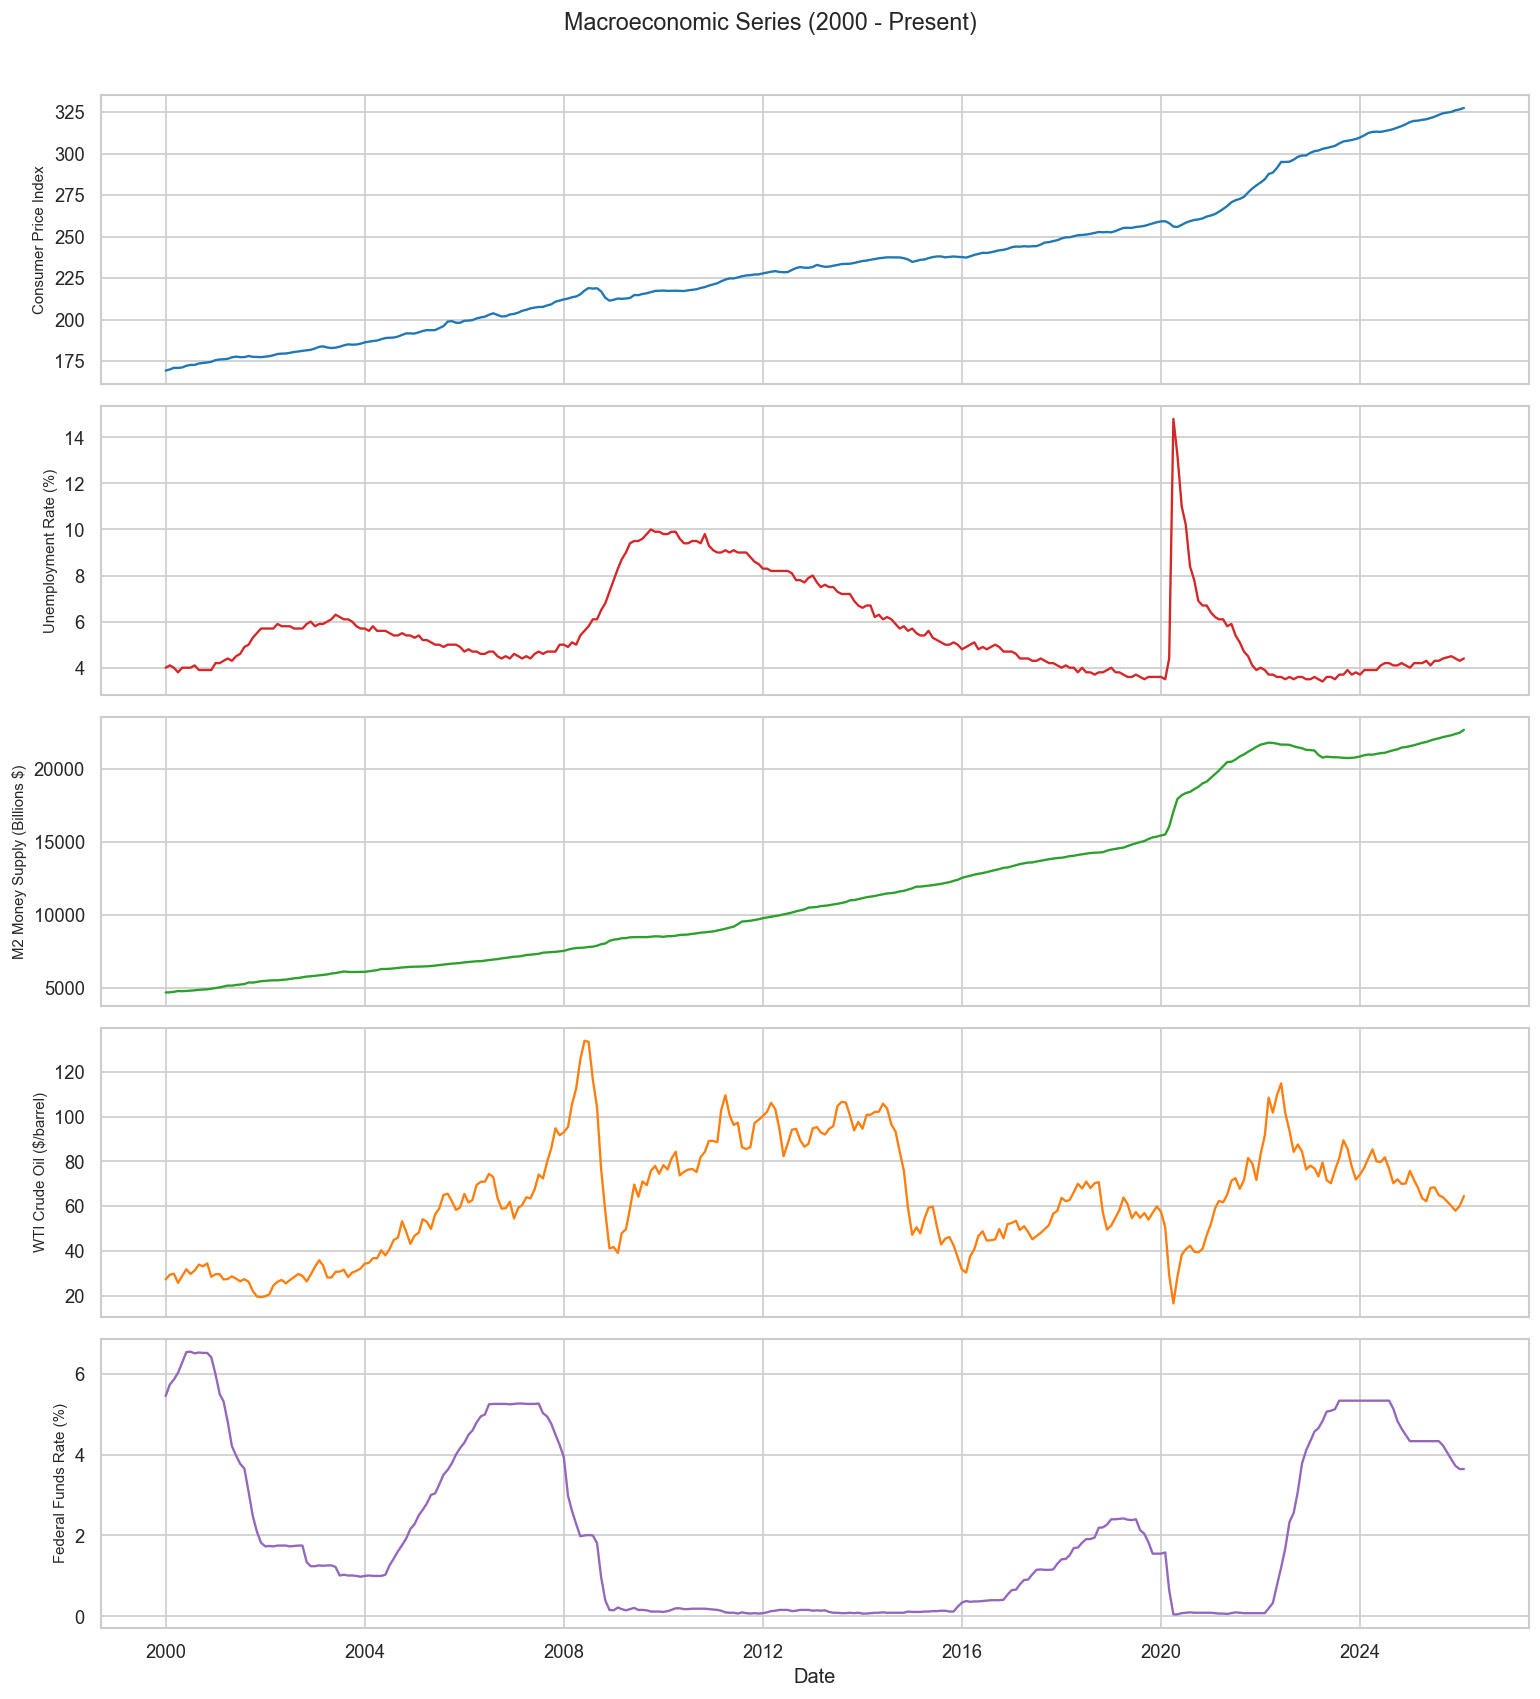

In [3]:
labels = {
    'CPI':      'Consumer Price Index',
    'UNRATE':   'Unemployment Rate (%)',
    'M2':       'M2 Money Supply (Billions $)',
    'OIL':      'WTI Crude Oil ($/barrel)',
    'FEDFUNDS': 'Federal Funds Rate (%)',
}

fig, axes = plt.subplots(5, 1, figsize=(13, 14), sharex=True)
colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd']

for ax, col, color in zip(axes, df.columns, colors):
    ax.plot(df.index, df[col], color=color, linewidth=1.4)
    ax.set_ylabel(labels[col], fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[-1].set_xlabel('Date')
fig.suptitle('Macroeconomic Series (2000 - Present)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/time_series.png', bbox_inches='tight')
plt.show()

## 3. Correlation Heatmap

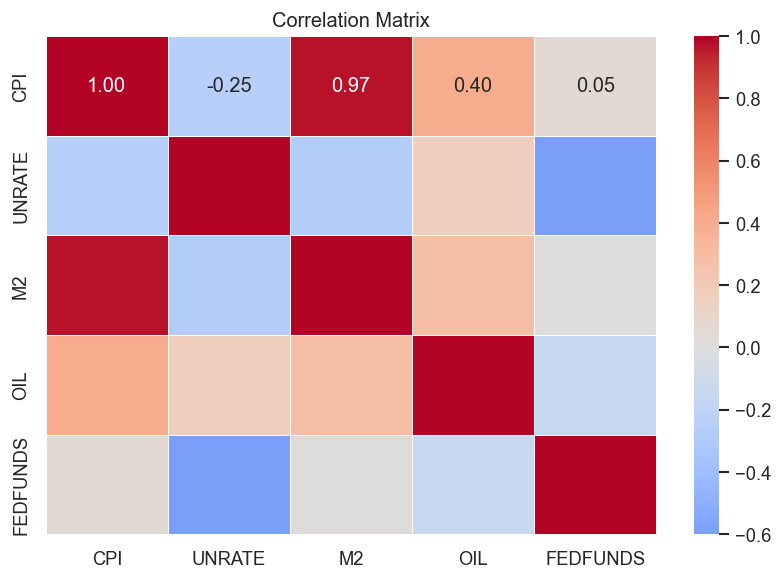

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df.corr().round(2), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 4. ACF / PACF Plots

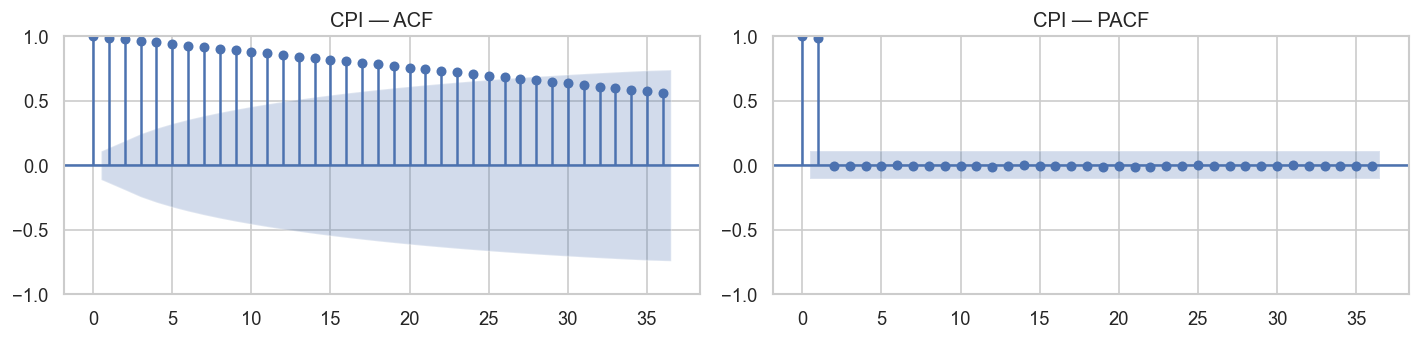

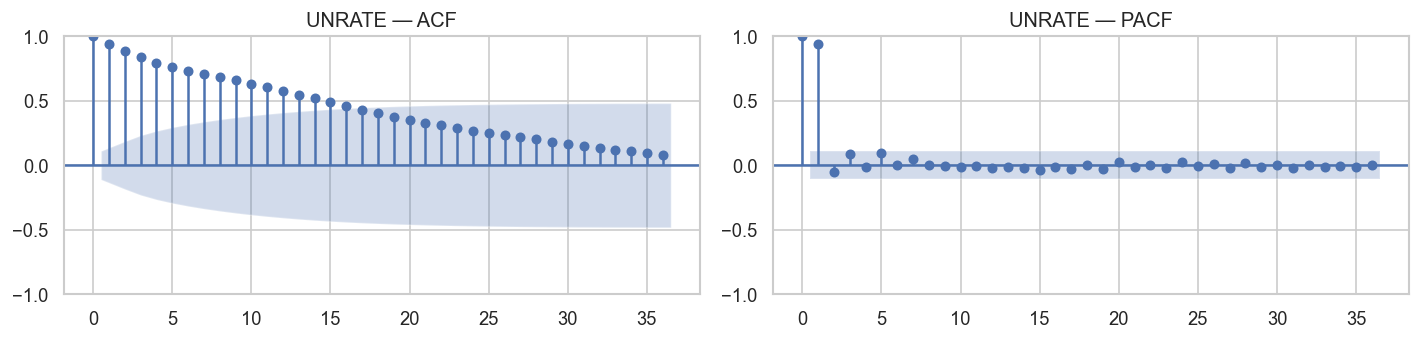

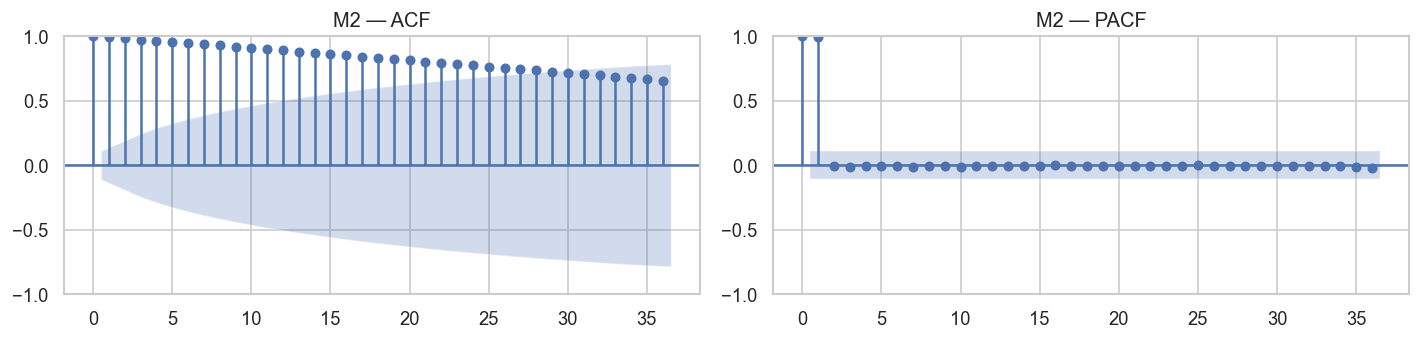

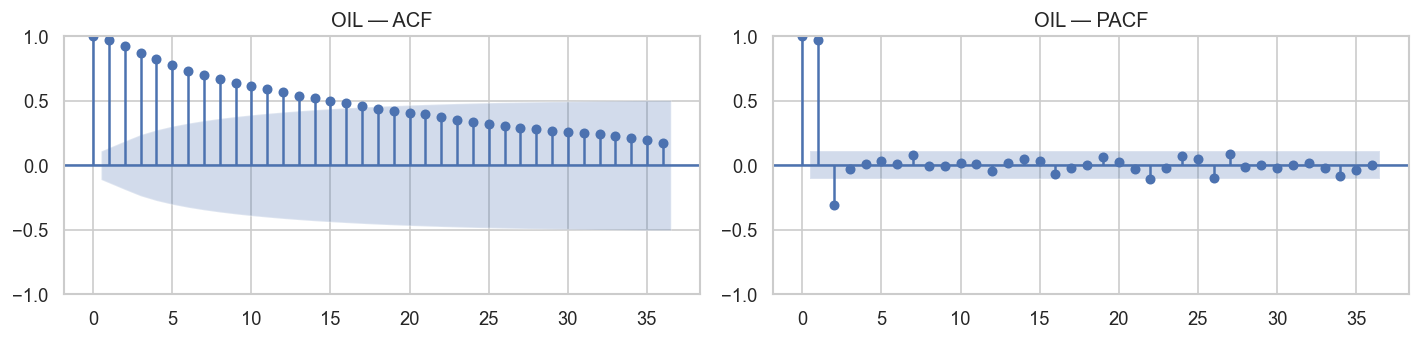

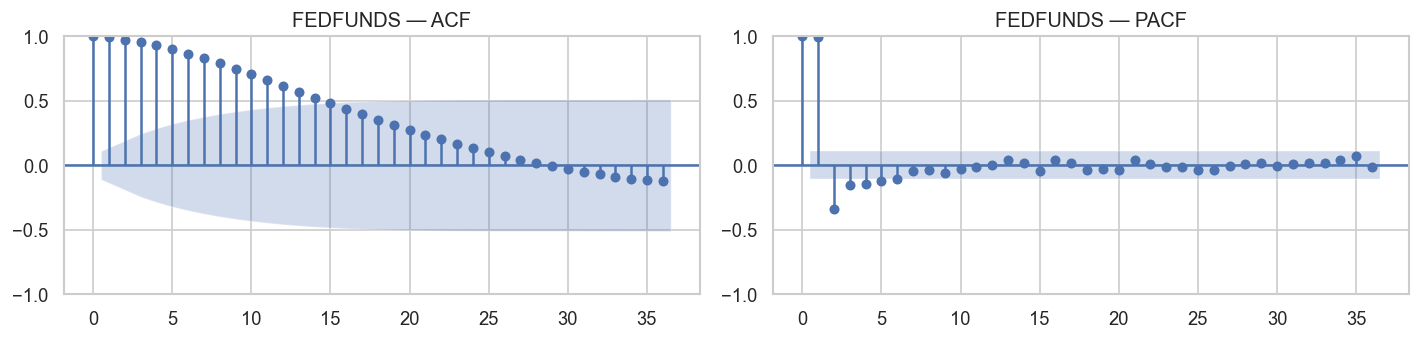

In [5]:
for col in df.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
    plot_acf(df[col].dropna(),  lags=36, ax=ax1, title=f'{col} — ACF')
    plot_pacf(df[col].dropna(), lags=36, ax=ax2, title=f'{col} — PACF', method='ywm')
    plt.tight_layout()
    plt.savefig(f'../outputs/acf_pacf_{col}.png', bbox_inches='tight')
    plt.show()

## 5. Seasonal Decomposition

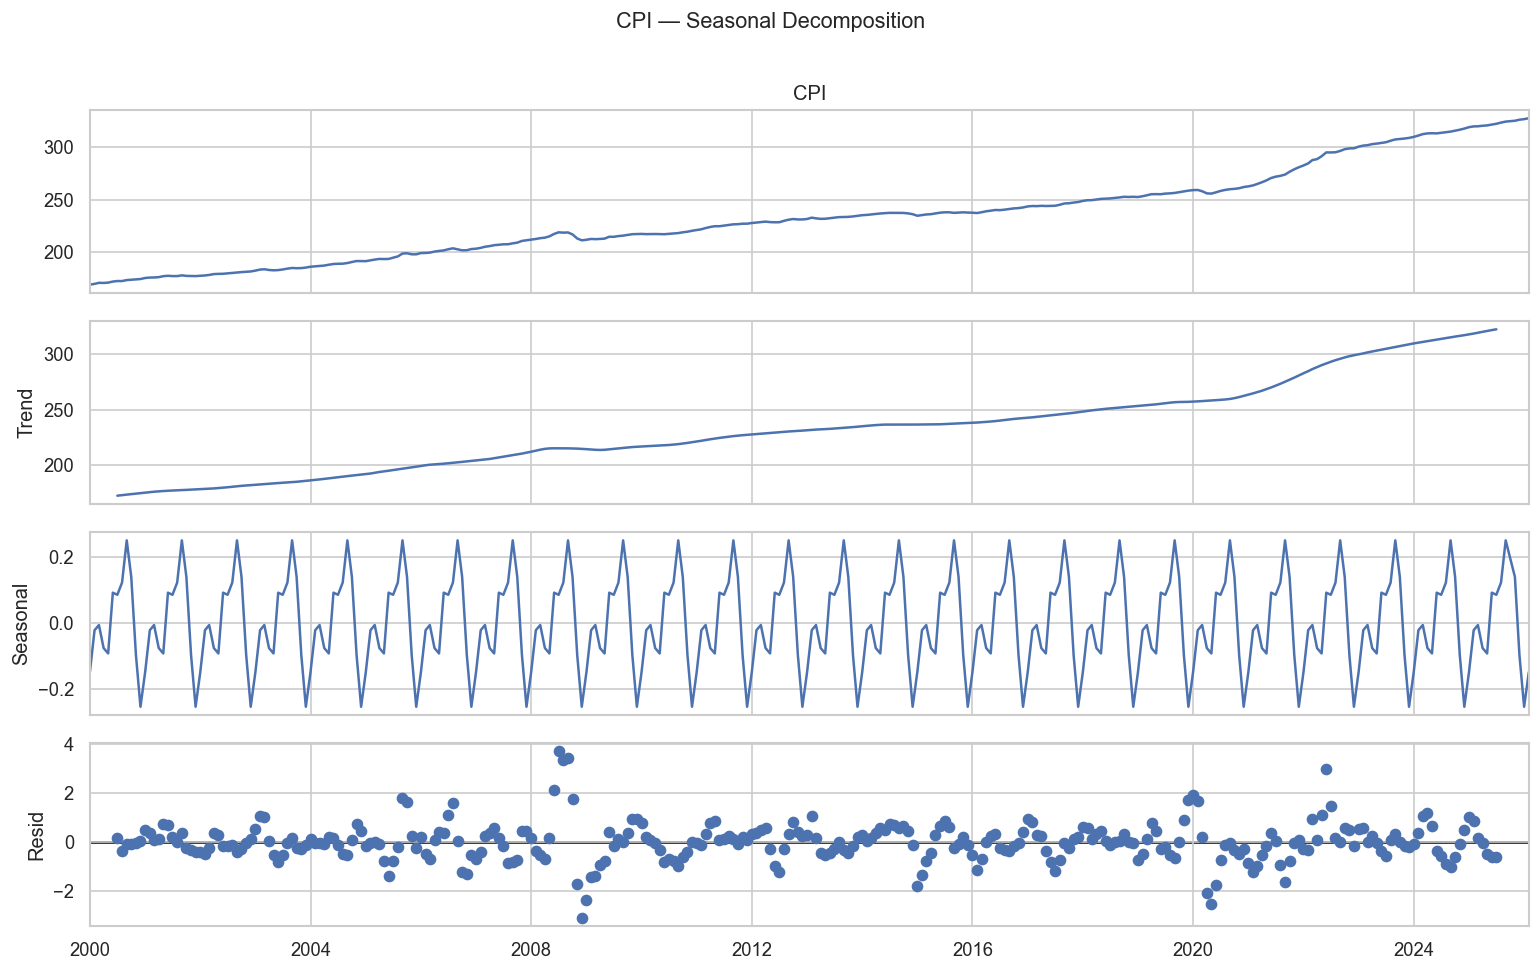

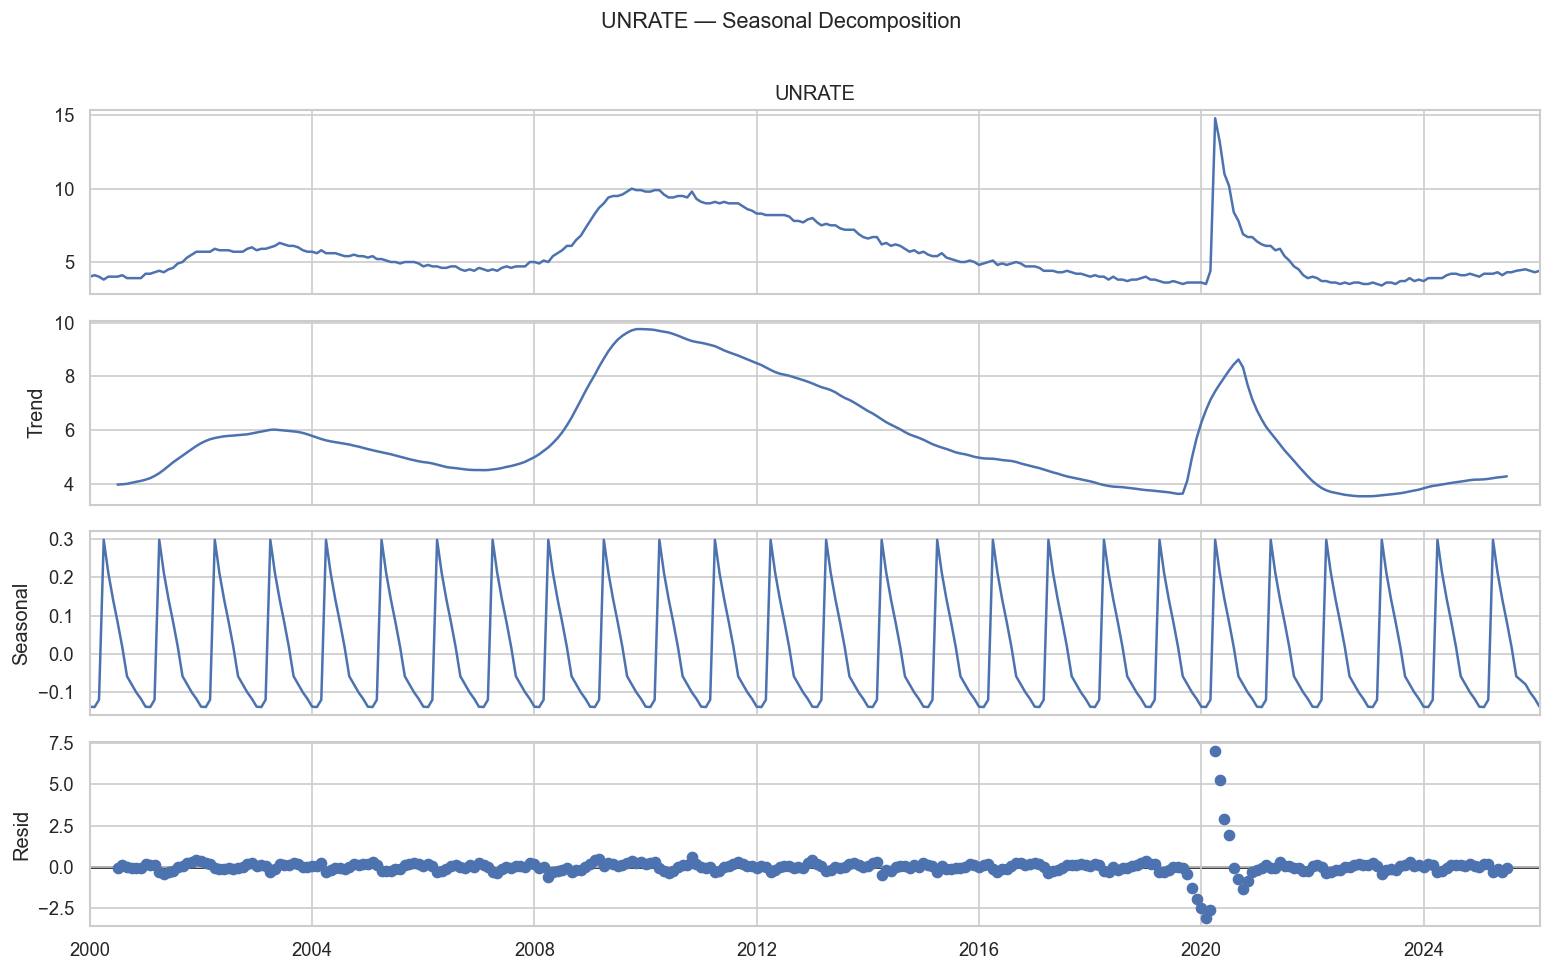

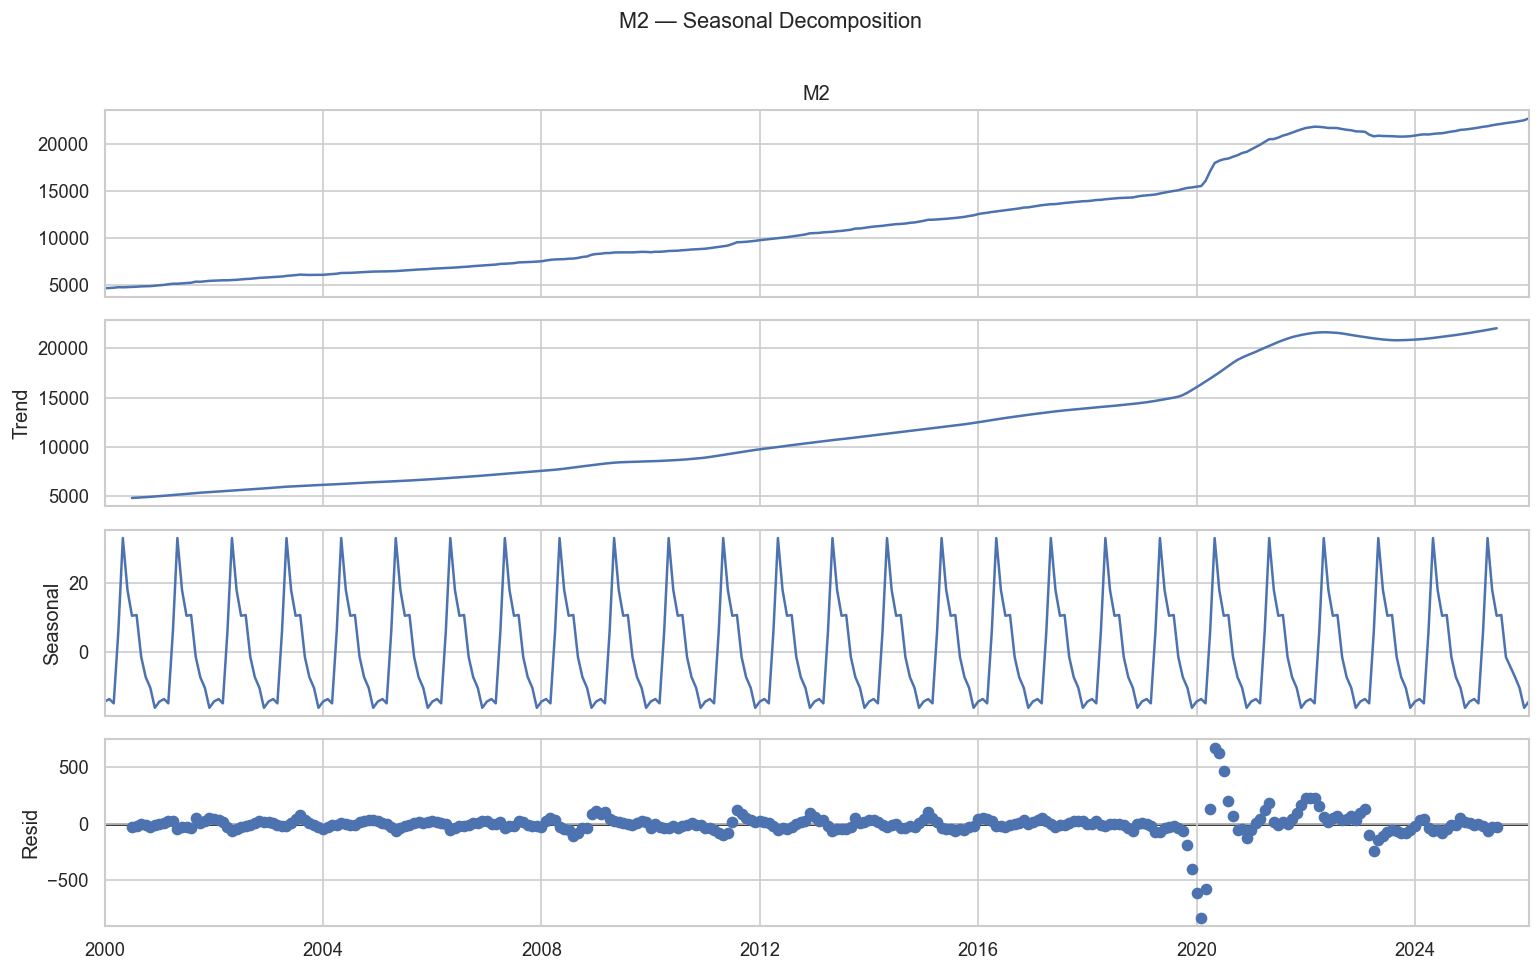

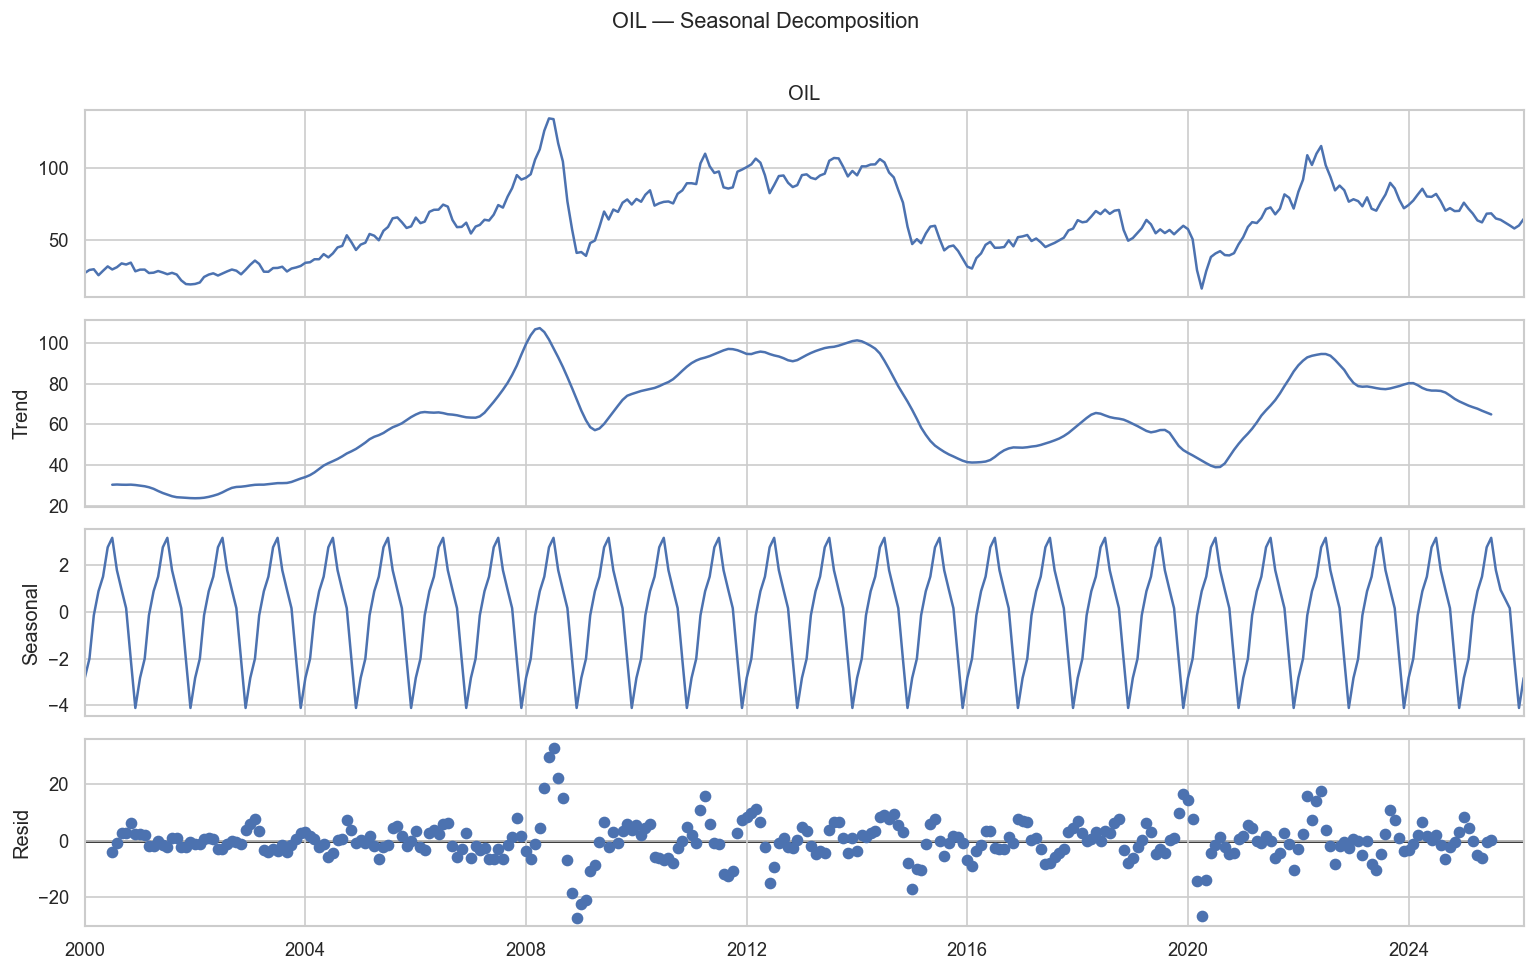

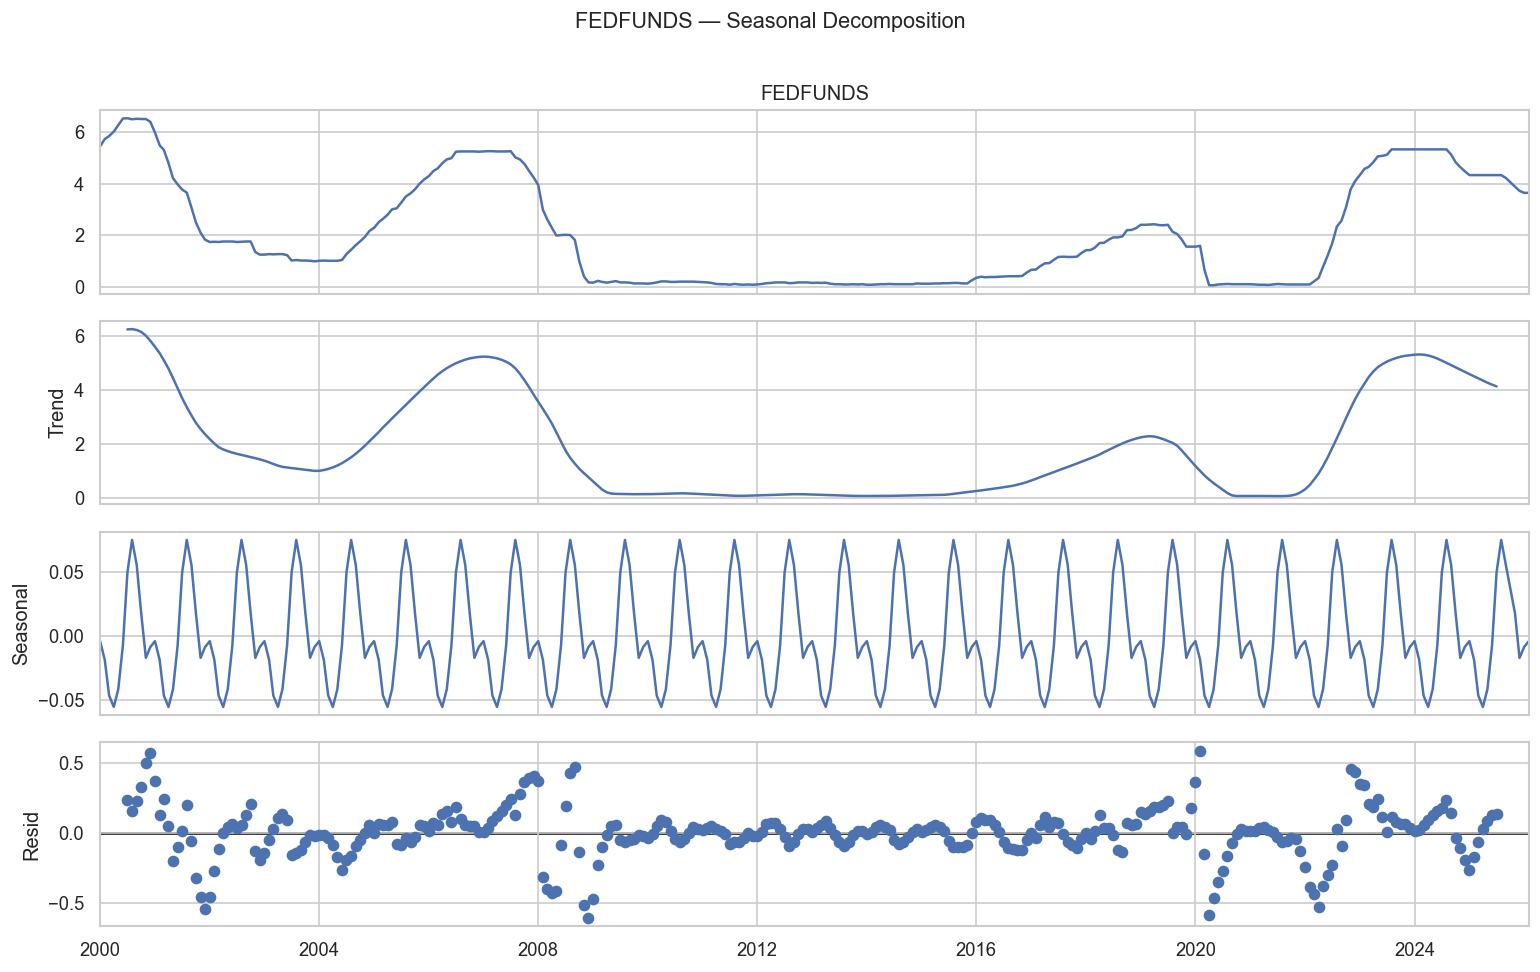

In [6]:
for col in df.columns:
    result = seasonal_decompose(df[col].dropna(), model='additive', period=12)
    fig = result.plot()
    fig.set_size_inches(13, 8)
    fig.suptitle(f'{col} — Seasonal Decomposition', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'../outputs/decomp_{col}.png', bbox_inches='tight')
    plt.show()